(chap_m2s1)=
# Introduction to Machine Learning in Healthcare
**Content creators:** [Samantha](https://github.com/samantha-u)

:::{admonition} Chapter Overview
:class: tip

* There is increasing interest in applying machine learning to healthcare, with some systems already deployed
* Some types of machine learning are supervised learning, unsupervised learning and reinforcement learning
* Logistic regression is one type of supervised model that can handle tabular data
* Understanding differences in algorithm architectures helps you to know what your model is doing and how you can improve it
:::

In [1]:
"""
These are imports that help the rest of the code on this page run.
"""

%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
from myst_nb import glue
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
"""
This code generates a simple synthetic dataset. This code section specifically was generated with the support of generative AI.
"""

# Set a random seed for reproducibility
np.random.seed(21)

# Number of patients
n = 1000

# Generate clean features
age = np.random.normal(loc=55, scale=15, size=n).clip(18, 90)
heart_rate = np.random.normal(loc=75, scale=12, size=n).clip(40, 180)
blood_pressure = np.random.normal(loc=120, scale=15, size=n).clip(80, 200)

# # Add feature noise
# age += np.random.normal(0, 2, n)              # ±2 years noise
# heart_rate += np.random.normal(0, 5, n)       # ±5 bpm noise
# blood_pressure += np.random.normal(0, 8, n)   # ±8 mmHg noise

# Keep values in realistic ranges
age = np.clip(age, 18, 90).astype(int)
heart_rate = np.clip(heart_rate, 40, 180)
blood_pressure = np.clip(blood_pressure, 80, 200)

# Generate outcome probabilities
logit = (
    -9.8
    + 0.05 * age
    + 0.04 * heart_rate
    + 0.03 * blood_pressure
)

prob = 1 / (1 + np.exp(-logit))
outcome = np.random.binomial(1, prob)

# Add label noise: flip 10% of labels
flip_rate = 0.01
flip_idx = np.random.choice(n, size=int(flip_rate * n), replace=False)
outcome[flip_idx] = 1 - outcome[flip_idx]

# Create DataFrame
patient_dataset = pd.DataFrame({
    "age": age,
    "heart_rate": heart_rate,
    "blood_pressure": blood_pressure,
    "patient_outcome": outcome
})

## Getting Started

There is growing interest in how machine learning can be leveraged into healthcare settings. One exciting example is CHARTwatch, an artificial intelligence early warning system developed at St. Michael’s Hospital. This system:
- Monitors hospital patients in real-time​
- Identifies those at high risk of unexpected death or transfer to intensive care​
- Sends alerts to enable early intervention by clinical team

**A study showed that this system reduced risk of unanticipated death in hospitalized patients by 26%** {cite:p}`verma_2024`. These results show that machine learning can have a role to play in reducing unexpected deaths of patients in hospitals.

:::{admonition} Clinical Question
:class: info
In the case of this system, we can think about the following clinical question:
* **Can we predict patient deterioration (using simple features)?​**
  * **What are we trying to predict?** Unexpected death or ICU transfer​
  * **What information do we have?** Blood pressure, age, heart rate

*Here, machine learning can formalize patterns and support early alerts.*
:::

## How Machine Learning Becomes Clinical
Specifically when thinking about clinical applications, there's a number of steps to work towards development and deployment. Just building the model is not enough to get in into clinical use! The pipeline below in {numref}`ml-clinical` is an example of what this can look like.

(ml-clinical)=
```{figure} mlclinical.png
:width: 80%
:alt: pipeline for ML for healthcare development

This flowchart shows the steps involved in preparing a machine learning model for use in a healthcare setting.

```

- **Patient Health Data**: Health data from patients is generally used in models for clinical settings. Given the sensitive nature of this sort of data, there are often additional concerns with data privacy compared to working with other kinds of data.
- **Model Development**: Model development involves creating training a model. In practice, this often means training many, many models, comparing them and seeing what works best.
- **Model Validation (new dataset)**: Before deployment models should be evaluated on data that was not used during training. Ideally, if the model is designed to be broadly applicable, this data could come from another centre. This is discussed in further detail in another section.
- **Final ML Model**: This produces a finalized ML model that is ready to be evaluated.
- **Silent Trial & Evaluation**: In a silent trial, ML models are evaluated on prospective patients in real-time, but model results are not shared with healthcare providers. This enables research teams to assess the model without impacting patient care.
- **Model Deployment in Hospital**: Deployment in the hospital can involve integration into existing technical infrastruction. This enables the model to access the data needed to make prediction.
- **Integration in Clinical Care**: Beyond technical integration, a model is only useful if clinicians are actually using it. It thus needs to fit into clinical workflows and be accepted by clinicians.
- **Health Canada Software as a Medical Device (SaMD) Approval**: ML products can be classified as software as a medical device. There are pathways with Health Canada for approval of such devices.

## What is Machine Learning
Machine learning is about training a computer model to find patterns within data. Some times of machine learning are:
1. **Supervised Learning** - training a computer model to understand the **relationship between data and its label** (e.g., outcome).
2. **Unsupervised Learning** - training a computer model to understand **patterns within data without explicit guidance of the label** (discussed in another chapter)
3. **Reinforcement Learning** - training a computer model through iterative feedback (i.e., trial and error) so that it may **optimize task performance** over time (not covered in this site)

## Supervised Learning
In the training phase of these models, you use labelled data, so the model can learn relationships. When you later use a supervised model, you can use it to predict labels for data that is otherwise unlabelled. This concept is illustrated below in {numref}`supervised-model`.

(supervised-model)=
```{figure} supervisedmodel.png
:width: 80%
:alt: training and use phase of supervised models

Data used for training is labelled, producing a model that can be used to predict missing labels.

```

As shown in {numref}`classreg`, there are two types of supervised learning:
1. **Regression**: predicts continuous numerical values, e.g., length of hospital stay, treatment dosage, future biomarker values
2. **Classification**: predicts discrete categories/classes, e.g., whether or not patient will experience adverse drug reaction, if lung nodule is malignant or benign

(classreg)=
```{figure} regclass.png
:width: 40%
:alt: classification vs. regression

Regression predicts to continuous values, think of those you can place on the number line. On the other hand, classification predicts categories.
```

## Tabular Data
Tabular data is structured in rows and columns - think of a spreadsheet!
* Each row represents an observation or ***training example***
* Each column represents a ***feature***

Tabular data can often feature mixted types of data and missing values (*discussed in another module*).

For this clinical problem, our data may look something like this. Each row represents a patient interaction. This is a supervised learning problem as we can use patient outcome as a label.

In [3]:
# This will display the first 5 rows of the dataset
print(patient_dataset.head())

# This will display the counts for each label
print("\nOutcome distribution:")
print(patient_dataset["patient_outcome"].value_counts())

   age  heart_rate  blood_pressure  patient_outcome
0   54   93.525204       95.823634                1
1   53   76.145234      149.005544                0
2   70   83.369705      125.011079                1
3   36   60.268840      118.133046                0
4   66   83.641184      124.170756                1

Outcome distribution:
patient_outcome
0    611
1    389
Name: count, dtype: int64


:::{admonition} Structuring This Problem
:class: info
In the case of this system, we can think about the following clinical question:
* **Input Features​**: Heart Rate, Blood Pressure, Age
* **Output Label**: Risk Label - 1 = at risk of deterioration, 0 = not at risk

*Here, machine learning can formalize patterns and support early alerts.*
:::

In [4]:
# assign the features (X) 
X = patient_dataset[["age", "heart_rate", "blood_pressure"]]

# assign the labels (y)
y = patient_dataset["patient_outcome"]

This is considered a **binary classification** problem as there are two possible labels being predicted (i.e., like a yes/no question).

## Logistic Regression
Logistic regression is one type of supervised model we can train. We are starting here because it is simple and interpretable.

Logistic regression fits a curve (the logistic function, shown in Equation {eq}`logregmath`) to the labeled data.

```{math}
:label: logregmath
f(z) = \frac{1}{1 + e^{-(b_1 \cdot x_1 + b_2 \cdot x_2 + ... + b_n \cdot x_n + b_0 )}}
```

Logistic regression is:
* A weighted combination of features
* Produces a probability between 0 and 1

We can understand where the outputs come from (***interpretability***) by inspecting the relative weightings of each feature. 

In this model...
* Positive coefficient → increases risk
* Negative coefficient → decreses risk
* Magnitude → strength of association (* if features are normalized - *see other module*)

We can ask questions like:
* "Does higher heart rate increase risk?"
* "Is age more important than blood pressure?"

**Since this is straightforward, the model may be easier to explain and trust.**

## Implementing This Model
This model can be implemented using the Sklearn library. Additional documentation is available {cite:p}`linreg_ref`.

In [5]:
# Fit a logistic regression model to the data
fit_model = LogisticRegression(random_state=0).fit(X, y)

# We can see the accuracy of this model on the training data
model_accuracy = fit_model.score(X, y)
print(f'Model accuracy: {model_accuracy*100}%')

Model accuracy: 69.3%


This accuracy is OK, but not quite perfect! To get a better sense of what's going on here, we can plot a confusion matrix to understand where the accuracy is coming from.

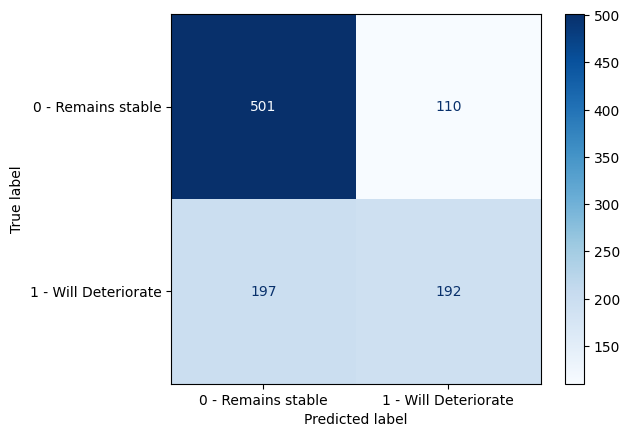

In [6]:
# Make predictions on the training set
y_train_pred = fit_model.predict(X)

# Generate the values for the confusion matrix
cm = confusion_matrix(y, y_train_pred)

# Visualize the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0 - Remains stable', '1 - Will Deteriorate'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# glue('fig_cm', disp.figure_)

```{glue:figure} fig_cm
:align: center
:width:80%
:name: fig-cm
Confusion matrix for logistic regression model.
```

Looking at the confusion matrix, we can see that most of the patients who remain stable are predicted to remain stable. However, only around half the patients who deteriorate are predicted to do so. This implies that the model may not work be ready to be deployed!

:::{Admonition} Why might this not be working so well?
:class: dropdown
The training examples contain more patients who remain stable than those who deteriorate. Some types of models struggle when there is an imbalanced number of examples in each class. We call this **class imbalance**. This is discussed in further detail *in another module*.
:::

We can also inspect the coefficients of the model.

In [7]:
# Examine model coefficients
print("Coefficients:", fit_model.coef_)
print("Intercept:", fit_model.intercept_)

Coefficients: [[0.05334319 0.03102967 0.03403639]]
Intercept: [-9.85568385]


All of the coefficients are positive, implying that higher heart rate, age, and blood pressure are all associated with increased risk of deterioration in our model. If we wanted to examine the relative magnitudes, we would have needed to normalize the input data for each feature to be in the same range, *as described in another module*.

With this code ready to go, we can look at exploring other types of models and seeing how they perform on different types of data!